In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1: Load Dataset

The dataset is loaded from the raw data folder. This step initializes the analysis by importing healthcare insurance data into a DataFrame.

In [26]:
df = pd.read_csv("../data/raw/healthcare_raw.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Insight:
The dataset contains information such as age, gender, BMI, smoking status, and insurance charges.

In [27]:
df.shape

(1338, 7)

In [28]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

2: Understand Dataset:

This step helps to understand the structure of the dataset, including data types, number of records, and statistical summary.

In [29]:
df.info

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [30]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Insight:

The dataset contains information such as age, gender, BMI, smoking status, and insurance charges.

3: Check Missing Values


In [31]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Insight:
- Missing values were found in the smoker column
- These values must be handled before further analysis

4: Handle Missing Values

In [32]:
df['smoker'] = df['smoker'].fillna('no')

5: Remove Duplicates

In [33]:
df.duplicated().sum()

np.int64(1)

In [34]:
df = df.drop_duplicates()

Insight:

Removing duplicates prevents biased or repeated data from affecting results.

6: Feature Engineering

Categorical variables are converted into numerical format to make them suitable for analysis.


In [57]:
# Fix warning
df = df.copy()

import pandas as pd

# 🔹 Encoding
df['sex'] = df['sex'].map({'male':1, 'female':0})
df['smoker'] = df['smoker'].map({'yes':1, 'no':0})

# 🔹 Age group (FIXED)
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 50, df['age'].max()],
    labels=['Young', 'Adult', 'Senior'],
    include_lowest=True
)

# 🔹 BMI category (FIXED)
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, df['bmi'].max()],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese'],
    include_lowest=True
)

# 🔹 Family size
df['family_size'] = df['children'] + 1

In [36]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)
df.head()

,age,sex,bmi,children,smoker,charges,age_group,bmi_category,family_size,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,Young,Overweight,1,False,False,True
1,18,1,33.770,1,0,1725.55230,Young,Obese,2,False,True,False
2,28,1,33.000,3,0,4449.46200,Young,Obese,4,False,True,False
3,33,1,22.705,0,0,21984.47061,Adult,Normal,1,True,False,False
4,32,1,28.880,0,0,3866.85520,Adult,Overweight,1,True,False,False


In [37]:
df.head()

,age,sex,bmi,children,smoker,charges,age_group,bmi_category,family_size,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,Young,Overweight,1,False,False,True
1,18,1,33.770,1,0,1725.55230,Young,Obese,2,False,True,False
2,28,1,33.000,3,0,4449.46200,Young,Obese,4,False,True,False
3,33,1,22.705,0,0,21984.47061,Adult,Normal,1,True,False,False
4,32,1,28.880,0,0,3866.85520,Adult,Overweight,1,True,False,False


In [38]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   age               1337 non-null   int64   
 1   sex               1337 non-null   int64   
 2   bmi               1337 non-null   float64 
 3   children          1337 non-null   int64   
 4   smoker            1337 non-null   int64   
 5   charges           1337 non-null   float64 
 6   age_group         1337 non-null   category
 7   bmi_category      1337 non-null   category
 8   family_size       1337 non-null   int64   
 9   region_northwest  1337 non-null   bool    
 10  region_southeast  1337 non-null   bool    
 11  region_southwest  1337 non-null   bool    
dtypes: bool(3), category(2), float64(2), int64(5)
memory usage: 90.4 KB


Insight:
- Encoding helps in performing correlation and visualization
- Region is split into multiple columns using one-hot encoding

7: Distribution of Charges 


This plot shows how insurance charges are distributed across individuals.


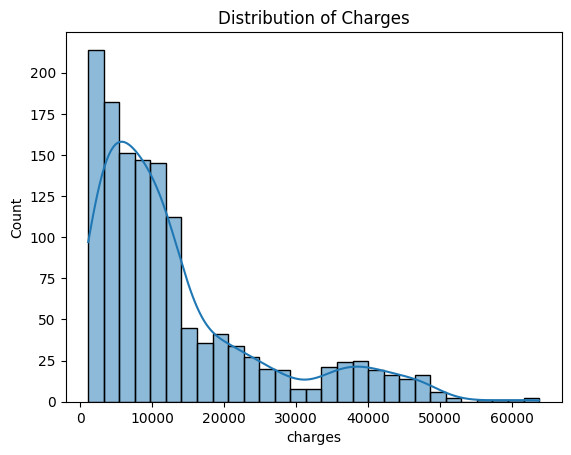

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Charges")
plt.show()

Insight:
- Charges are right-skewed
- Most people have lower charges, while a few have very high costs



8: Age vs Charges

This visualization shows the relationship between age and insurance charges.

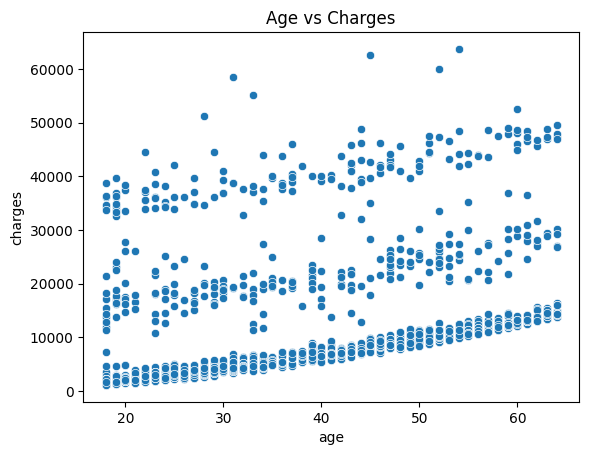

In [40]:
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

 Insight:
Charges increase as age increases, showing a positive correlation.

9: BMI vs Charges

This plot shows how BMI affects medical costs.


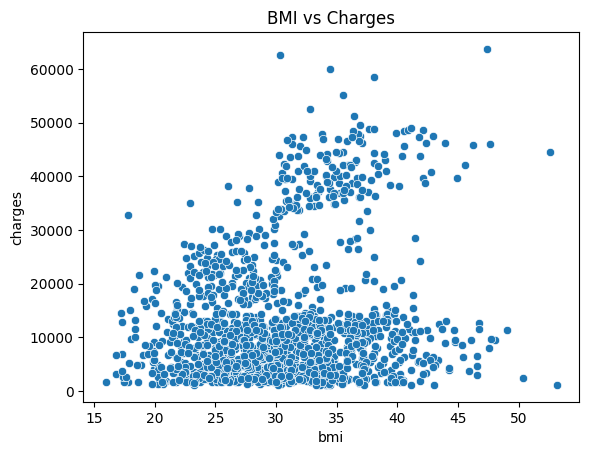

In [41]:
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

 Insight:
BMI has moderate influence on charges, especially at higher values.

In [42]:
df.dtypes

age                    int64
sex                    int64
bmi                  float64
children               int64
smoker                 int64
charges              float64
age_group           category
bmi_category        category
family_size            int64
region_northwest        bool
region_southeast        bool
region_southwest        bool
dtype: object

In [43]:
df['smoker'].isnull().sum()

np.int64(0)

In [44]:
df['smoker'] = df['smoker'].fillna(0)
df['smoker'] = df['smoker'].astype(int)

In [45]:
df = df[['smoker', 'charges']].copy()
df = df.dropna()
df = df.reset_index(drop=True)

In [46]:
df['smoker'] = df['smoker'].astype(int)
df['charges'] = pd.to_numeric(df['charges'], errors='coerce')

In [47]:
df['smoker_label'] = df['smoker'].map({0: 'No', 1: 'Yes'})

10: Smoker vs Charges

This plot compares medical charges between smokers and non-smokers.


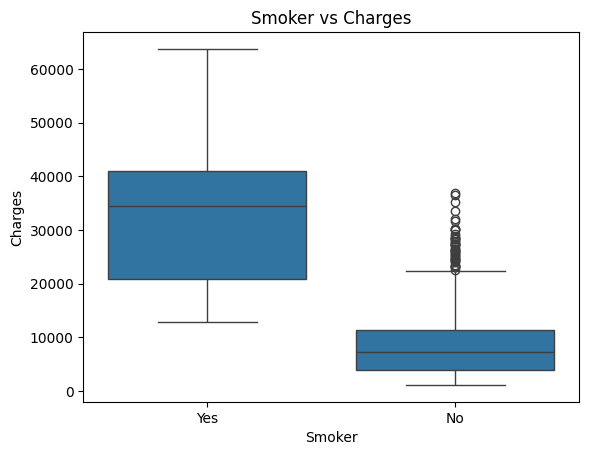

In [48]:
plt.figure()

sns.boxplot(
    x=df['smoker_label'].values,
    y=df['charges'].values
)

plt.title("Smoker vs Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")

plt.show()

Insight:

Smokers have significantly higher charges than non-smokers, making smoking the most impactful factor.

11: Correlation Heatmap


This heatmap shows relationships between numerical variables.

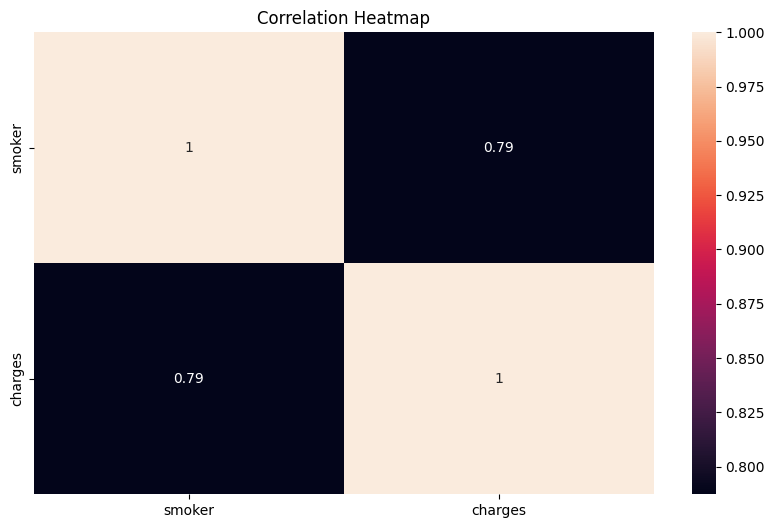

In [49]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Insight:
- Smoking has the strongest correlation with charges
- Age and BMI also influence charges
- Other variables have weak relationships

In [50]:
df = pd.read_csv("../data/raw/healthcare_raw.csv")

In [51]:
# remove missing values
df = df.dropna()

# encode
df['sex'] = df['sex'].map({'male':1, 'female':0})
df['smoker'] = df['smoker'].map({'yes':1, 'no':0})

# one-hot encoding
df = pd.get_dummies(df, columns=['region'], drop_first=True)


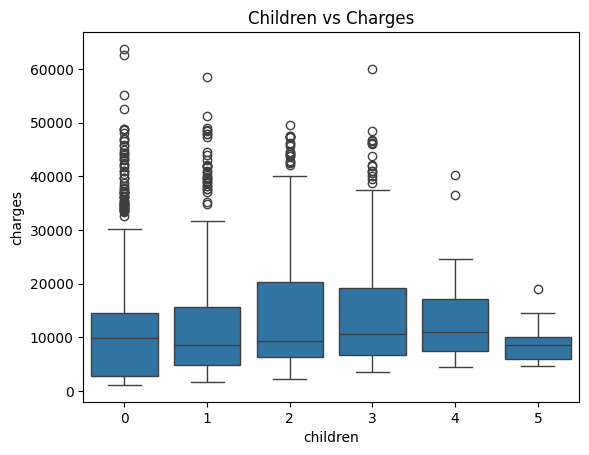

In [52]:
sns.boxplot(x='children', y='charges', data=df)
plt.title("Children vs Charges")
plt.show()

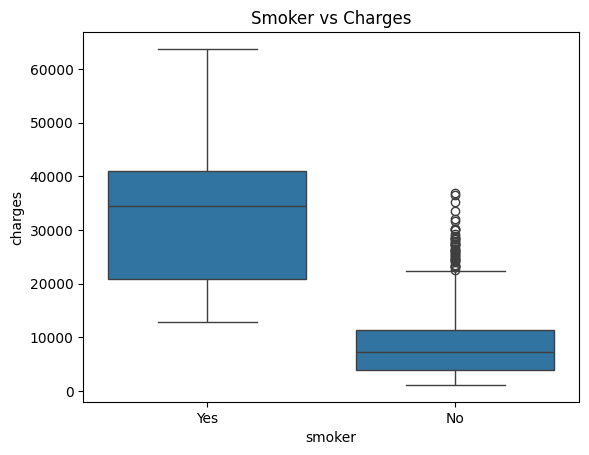

In [53]:
sns.boxplot(x=df['smoker'].map({0:'No',1:'Yes'}), y=df['charges'])
plt.title("Smoker vs Charges")
plt.show()

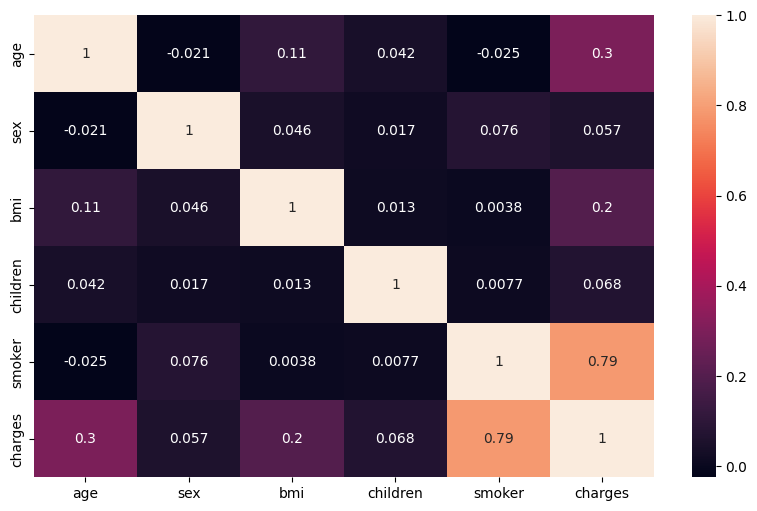

In [54]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

12: Save Clean Data

The cleaned dataset is saved for further use in visualization tools like Power BI.


In [55]:
df.to_csv("../data/processed/healthcare_cleaned.csv", index=False)

Insight:

The processed dataset is now ready for dashboard creation and business analysis.
